In [1]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from collections import Counter
from tqdm import tqdm
import shutil

In [2]:
data_path = r"D:\Datasets\neurite-oasis.v1.0"

In [3]:
output_data_dir = r"D:\Datasets\neurite-oasis-split"
train_dir = os.path.join(output_data_dir, "train")
val_dir = os.path.join(output_data_dir, "val")

print(f"Output data directory: {output_data_dir}")
print(f"Train directory: {train_dir}")
print(f"Val directory: {val_dir}")

Output data directory: D:\Datasets\neurite-oasis-split
Train directory: D:\Datasets\neurite-oasis-split\train
Val directory: D:\Datasets\neurite-oasis-split\val


In [4]:
# Calculate total number of subjects
# the folder name for each subject in the pattern: OASIS_OAS1_xxxx_MR1

subject_folders = [f for f in os.listdir(data_path) if f.startswith("OASIS_OAS1_") and f.endswith("_MR1")]
total_subjects = len(subject_folders)
print(f"Total number of subjects: {total_subjects}")


Total number of subjects: 414


Visualizing 10 random subjects:
  OASIS_OAS1_0125_MR1
  OASIS_OAS1_0232_MR1
  OASIS_OAS1_0127_MR1
  OASIS_OAS1_0046_MR1
  OASIS_OAS1_0422_MR1
  OASIS_OAS1_0033_MR1
  OASIS_OAS1_0382_MR1
  OASIS_OAS1_0384_MR1
  OASIS_OAS1_0397_MR1
  OASIS_OAS1_0404_MR1


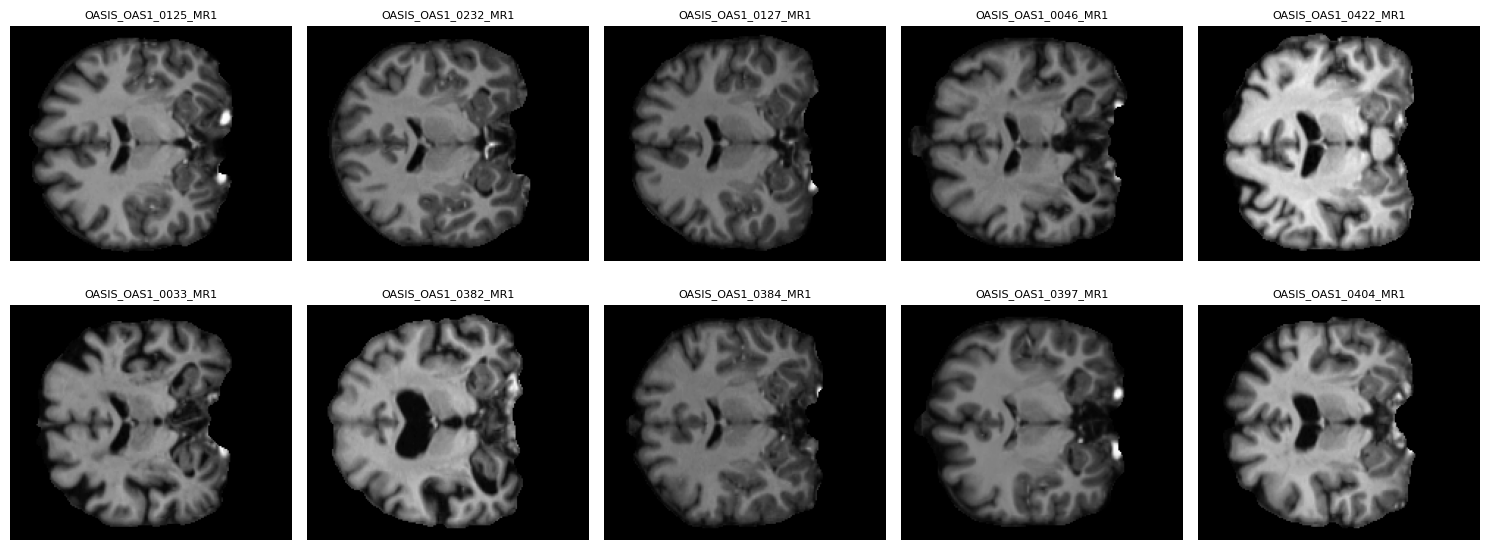

In [5]:
sample_subjects = random.sample(subject_folders, min(10, len(subject_folders)))
print(f"Visualizing {len(sample_subjects)} random subjects:")
for subject in sample_subjects:
    print(f"  {subject}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, subject in enumerate(sample_subjects):
    norm_file = os.path.join(data_path, subject, "aligned_norm.nii.gz")
    if os.path.exists(norm_file):
        img = nib.load(norm_file)
        data = img.get_fdata()
        
        middle_slice = data.shape[2] // 2
        axes[idx].imshow(data[:, :, middle_slice], cmap='gray')
        axes[idx].set_title(subject[:20], fontsize=8)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'File not found', ha='center', va='center')
        axes[idx].set_title(subject[:20], fontsize=8)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [6]:
dimension_voxel_info = []

for subject in tqdm(subject_folders, desc="Processing subjects"):
    norm_file = os.path.join(data_path, subject, "aligned_norm.nii.gz")
    if os.path.exists(norm_file):
        img = nib.load(norm_file)
        data = img.get_fdata()
        affine = img.affine
        
        dimension = tuple(data.shape)
        voxel_spacing = tuple(np.sqrt(np.sum(affine[:3, :3] ** 2, axis=0)))
        
        dimension_voxel_info.append({
            'subject': subject,
            'dimension': dimension,
            'voxel_spacing': voxel_spacing
        })

print(f"Total subjects processed: {len(dimension_voxel_info)}")

Processing subjects: 100%|██████████| 414/414 [00:48<00:00,  8.56it/s]

Total subjects processed: 414


In [7]:
dimension_voxel_combinations = [(info['dimension'], tuple(np.round(info['voxel_spacing'], 4))) for info in dimension_voxel_info]
combination_counter = Counter(dimension_voxel_combinations)

print(f"\nTotal unique dimension/voxel_spacing combinations: {len(combination_counter)}\n")
print("Top 5 most unique combinations:")
print("=" * 80)

for rank, (combo, count) in enumerate(combination_counter.most_common(5), 1):
    dimension, voxel_spacing = combo
    print(f"{rank}. Dimension: {dimension} | Voxel Spacing: {voxel_spacing}")
    print(f"   Count: {count} subjects")
    print()


Total unique dimension/voxel_spacing combinations: 1

Top 5 most unique combinations:
1. Dimension: (160, 192, 224) | Voxel Spacing: (np.float64(1.0), np.float64(1.0), np.float64(1.0))
   Count: 414 subjects



In [8]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

num_subjects = len(subject_folders)
num_train = int(0.8 * num_subjects)

train_subjects = subject_folders[:num_train]
val_subjects = subject_folders[num_train:]

print(f"Total subjects: {num_subjects}")
print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects: {len(val_subjects)}")

Total subjects: 414
Train subjects: 331
Val subjects: 83


In [9]:
for subject in tqdm(train_subjects, desc="Copying train subjects"):
    dest_dir = os.path.join(train_dir, subject)
    os.makedirs(dest_dir, exist_ok=True)

    for fname in ("aligned_norm.nii.gz", "seg35.nii.gz"):
        src_file = os.path.join(data_path, subject, fname)
        dest_file = os.path.join(dest_dir, fname)
        if os.path.exists(src_file):
            shutil.copy2(src_file, dest_file)
        else:
            print(f"Warning: {src_file} not found")

print(f"Train split complete: {len(train_subjects)} subjects copied")

Copying train subjects: 100%|██████████| 331/331 [00:01<00:00, 220.18it/s]

Train split complete: 331 subjects copied


In [10]:
for subject in tqdm(val_subjects, desc="Copying val subjects"):
    dest_dir = os.path.join(val_dir, subject)
    os.makedirs(dest_dir, exist_ok=True)

    for fname in ("aligned_norm.nii.gz", "seg35.nii.gz"):
        src_file = os.path.join(data_path, subject, fname)
        dest_file = os.path.join(dest_dir, fname)
        if os.path.exists(src_file):
            shutil.copy2(src_file, dest_file)
        else:
            print(f"Warning: {src_file} not found")

print(f"Val split complete: {len(val_subjects)} subjects copied")

Copying val subjects: 100%|██████████| 83/83 [00:00<00:00, 205.48it/s]

Val split complete: 83 subjects copied
